<div style="text-align: center;">

# Real Estate Portfolio Exercise: Risk Scores, Clusters, and Financial Metrics

</div>

This notebook walks through a full physical climate-risk workflow for a sample real-estate portfolio. It starts from a local CSV portfolio, registers that portfolio with the API, retrieves asset-level risk scores, explores hazard clusters, and then requests financial metrics at both cluster and portfolio level.

The workflow is:

1. Load the portfolio and inspect it before submission.
2. Register the portfolio and run asset-level risk analysis.
3. Review which hazard and indicator combinations are available.
4. Retrieve hazard clusters and inspect their spatial footprint.
5. Request financial metrics for one cluster and for the full portfolio.
6. Interpret exceedance curves, Value at Risk, and Expected Shortfall.

## 1. Setup and Configuration

When you run the notebook for the first time, select `.venv` as the interpreter. If you are unable to find the `.venv` interpreter, please follow the *Setup* instructions in the `README.md` to set it up.

The first cells load the libraries used throughout the notebook.
- `pandas` handles tabular portfolio data.
- `requests` is used for direct endpoint calls.
- `shapely` supports cluster geometry handling.
- `plotly` creates an interactive point map.
- the local helper modules provide portfolio maps plus financial-metric plots.

In [1]:
import os

import pandas as pd
import requests
from dotenv import load_dotenv
from shapely import MultiPolygon, Polygon

In [2]:
import sys
from pathlib import Path

NOTEBOOKS_ROOT = Path.cwd().parent
if str(NOTEBOOKS_ROOT) not in sys.path:
    sys.path.insert(0, str(NOTEBOOKS_ROOT))

from auxiliary_functions.financial_metrics_plots import plot_exceedance_curves, plot_var, plot_es
from auxiliary_functions.breakdown_charts import cluster_exposure_donut
from auxiliary_functions.geometry_maps_plots import show_portfolio, plot_clusters
from auxiliary_functions.pipeline_client import PhysicalAssetPipeline

In [3]:
# Render Plotly figures in both live notebooks and static notebook previews.
import plotly.io as pio

pio.renderers.default = "notebook+png"

The API configuration is read from `../../.env` so credentials and service URLs stay outside the notebook file. If you have not configured the `.env` file, please follow the *API credentials* instructions in the `README.md` to set it up.

This notebook uses both:

- the local `PhysicalAssetPipeline` helper, which wraps the multi-step risk and clustering workflow,
- and direct `requests.get(...)` calls for the financial-metric endpoints later in the notebook.

In [4]:
_ = load_dotenv("../../.env")
API_KEY = os.environ.get("ALPHA_KLIMA_API_KEY")
API_BASE = os.environ.get("ALPHA_KLIMA_API_BASE_URL", "").rstrip("/")
headers = {"X-API-Key": API_KEY, "Accept": "application/json"}

In [5]:
# Resolved API base URL, shown to confirm which service this notebook targets.
API_BASE

'https://platform.alpha-klima.com/prapi'

## 2. Load and Register the Portfolio

The workflow begins with a CSV portfolio of real-estate assets. Each row should include an asset identifier, asset metadata, coordinates, and a value field that can later be used in financial-loss calculations.

In [6]:
assets_df = pd.read_csv("../../resources/Residential Real Estate Portfolio.csv", dtype={"id": str})

In [7]:
assets_df.dropna(axis=1, how="all", inplace=True)

Displaying `assets_df` is a quick validation step before sending data to the API. At this point we check that the portfolio has the expected schema, that latitude and longitude are present, and that each asset has a value that can later be used in financial loss calculations.

In [8]:
assets_df

,id,asset_class,type,location,country,name,latitude,longitude,value
0,1,RealEstateAsset,Buildings/Residential,Europe,ES,Residential Asset 01,41.4159,2.2024,3140000
1,2,RealEstateAsset,Buildings/Residential,Europe,ES,Residential Asset 02,41.4062,2.1827,2118000
2,3,RealEstateAsset,Buildings/Residential,Europe,ES,Residential Asset 03,41.3810,2.1543,2917000
3,4,RealEstateAsset,Buildings/Residential,Europe,ES,Residential Asset 04,38.0163,-3.3759,602000
4,5,RealEstateAsset,Buildings/Residential,Europe,ES,Residential Asset 05,38.0058,-3.3670,1875000
5,6,RealEstateAsset,Buildings/Residential,Europe,ES,Residential Asset 06,38.0180,-3.3759,2365000
6,7,RealEstateAsset,Buildings/Residential,Europe,ES,Residential Asset 07,38.0266,-3.3668,1542000
7,8,RealEstateAsset,Buildings/Residential,Europe,ES,Residential Asset 08,37.4036,-5.9829,247000
8,9,RealEstateAsset,Buildings/Residential,Europe,ES,Residential Asset 09,37.3851,-5.9984,499000
9,10,RealEstateAsset,Buildings/Residential,Europe,ES,Residential Asset 10,37.4116,-6.0354,1224000


The map below is a second validation step. It helps confirm that the assets are located where you expect and provides a quick sense of how financial exposure is distributed spatially.

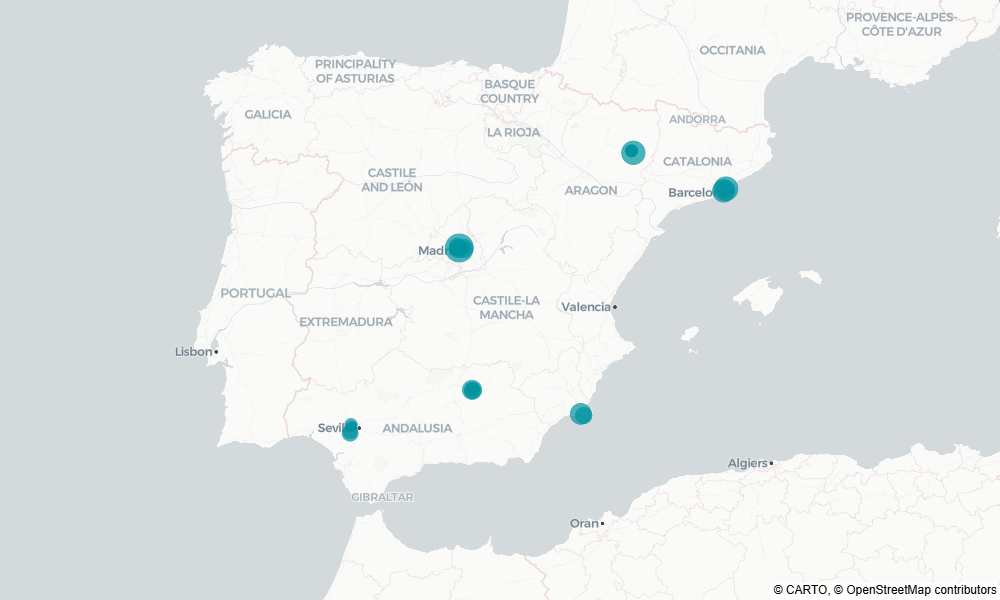

In [9]:
show_portfolio(
    latitudes=assets_df["latitude"].to_list(),
    longitudes=assets_df["longitude"].to_list(),
    asset_ids=assets_df["id"].to_list(),
    names=assets_df["name"].to_list(),
    values=assets_df["value"].to_list(),
)

The next cell registers the portfolio with the physical-assets pipeline and immediately runs the asset-level risk analysis.

The `PhysicalAssetPipeline` helper does three things behind the scenes:

1. creates a portfolio on the API and stores the returned `portfolio_code`,
2. uses method `run_risk_analysis` to trigger the risk pipeline,
3. uses method `run_clustering` to trigger the clustering calculation and aggregation metodology to get financial metrics at the cluster/portfolio level.

The returned `portfolio_code` is the handle used throughout the rest of the notebook.

> Warning: this remote calculation may take a few minutes.

In [10]:
portfolio = {
    "portfolio": {"assets": assets_df.to_dict("records")},
    "portfolio_name": "example",
}

pipeline = PhysicalAssetPipeline(
    api_base=API_BASE,
    api_key=API_KEY,
    portfolio=portfolio,
)
portfolio_code = pipeline.portfolio_code

risk_results = pipeline.run_risk_analysis(requested_results=[f"api/physical-asset-portfolios/{portfolio_code}/assets/risks"])
asset_level_risk = risk_results[f"api/physical-asset-portfolios/{portfolio_code}/assets/risks"]

---

## 3. Review Asset-Level Risk Scores

The asset-level risk response is nested, so the first helper functions convert it into easier review tables:

- `available_hazards` lists hazard and indicator combinations returned by the risk analysis.
- `risk_scores_from_hazards` extracts a tidy table for one hazard-indicator pair.

This makes it easier to move from a general inventory view to a specific analytical slice.

In [11]:
def available_hazards(asset_level_risk: list[dict]) -> pd.DataFrame:
    """Returns a table with all available hazards-indicators combinations for risk score metrics (acute + chronic)."""

    hazards = set()
    for data in asset_level_risk:
        hazard_data = {"hazard": data["hazard"], "indicator": data["indicator"]}
        hazards.add(frozenset(hazard_data.items()))

    df = pd.DataFrame(
        [dict(h) for h in hazards]
        )[["hazard", "indicator"]].sort_values(
            by=["hazard", "indicator"]
        ).reset_index(
            drop=True
    )
    
    return df

def risk_scores_from_hazards(asset_level_risk: list[dict], *, hazard: str, indicator: str) -> pd.DataFrame:
    rows = []
    for data in asset_level_risk:
        if data["hazard"] != hazard:
            continue
        if data["indicator"] != indicator:
            continue
        
        row = {
            "asset_id": data["client_asset_id"],
            "scenario": data["scenario"],
            "time_horizon": data["forecast_horizon"],
            "risk_score": data["risk_score"]
        }

        rows.append(row)

    df = pd.DataFrame(rows).sort_values(by=["scenario", "time_horizon", "asset_id"]).reset_index(drop=True)

    return df

Start by listing the available hazard-indicator combinations. This tells you what the current portfolio run produced and which combinations are valid to inspect in the next step.

In [12]:
available_hazards(asset_level_risk)

,hazard,indicator
0,ChronicHeat,cooling_degree_days/index
1,ChronicHeat,heating_degree_days/index
2,CoastalInundation,flood_depth
3,Drought,cdd
4,Drought,spi6
5,Fire,fire_probability
6,FreezingRain,freezing_rain_probability
7,Hail,hail_probability
8,Landslide,landslide_susceptability
9,RiverineInundation,flood_depth


The example below selects `Drought` with the `cdd` indicator and compares scores across assets, scenarios, and horizons.

Risk scores are ordinal summaries rather than physical units. They are most useful for relative comparison across assets and climate contexts.

In [13]:
hazard = "Drought"
indicator = "cdd"

risk_scores_from_hazards(asset_level_risk, hazard=hazard, indicator=indicator)

,asset_id,scenario,time_horizon,risk_score
0,1,historical,1971 - 2010,2
1,10,historical,1971 - 2010,3
2,11,historical,1971 - 2010,3
3,12,historical,1971 - 2010,3
4,13,historical,1971 - 2010,3
...,...,...,...,...
191,5,ssp585,2035 - 2065,3
192,6,ssp585,2035 - 2065,3
193,7,ssp585,2035 - 2065,3
194,8,ssp585,2035 - 2065,3


---

## 4. Review Hazard Clusters

Clustering groups assets that are exposed to the same acute-hazard footprint. This matters because financial losses can be spatially correlated: nearby assets may be affected by the same event rather than behaving independently.

Each acute hazard uses its own spatial method, so the cluster layout depends on the hazard being clustered. The clustering methods are described in the platform documentation.

> Warning: the clustering run may take a few minutes.

In [14]:
clustering_results = pipeline.run_clustering(requested_results=[
    f"api/physical-asset-portfolios/{portfolio_code}/clusters",
    f"api/physical-asset-portfolios/{portfolio_code}/clusters/assets"
    ])
clusters = clustering_results[f"api/physical-asset-portfolios/{portfolio_code}/clusters"]
asset2cluster = clustering_results[f"api/physical-asset-portfolios/{portfolio_code}/clusters/assets"]

These helpers reshape the clustering output into a more interpretable form:

- `available_clustering_hazards` lists which hazards have cluster results.
- `get_clusters_by_hazard` joins cluster definitions with their assigned assets.
- `plot_clusters_by_hazard` helps visualize the returned hazard footprints on a map.

In [15]:
def available_clustering_hazards(clusters: list[dict]) -> pd.DataFrame:
    """Returns a table with all available hazard combinations for clustering (only acute)."""
    
    hazards = set()
    for data in clusters:
        hazards.add(data["hazard"])

    df = pd.DataFrame(
        [{"hazard": h} for h in hazards]
        ).sort_values(
            by="hazard"
        ).reset_index(
            drop=True
    )
    
    return df

def get_clusters_by_hazard(clusters: list[dict], asset2cluster: list[dict], *, hazard: str) -> pd.DataFrame:
    rows = []
    for data in clusters:
        if data["hazard"] != hazard:
            continue

        cluster_id: int = data["cluster_id"]
        cluster_name: str = data["cluster_name"]
        value: float = data["value"]
        geometry: Polygon | MultiPolygon = data["geometry"]

        assets = set()
        for a2c in asset2cluster:
            if a2c["cluster_name"] != cluster_name:
                continue

            assets.add(a2c["client_asset_id"])
        
        row = {
            "cluster_id": cluster_id,
            "assets": sorted(assets),
            "cluster_name": cluster_name,
            "value": value,
            "geometry": geometry,
        }

        rows.append(row)

    return pd.DataFrame(rows)

Use the hazard list to choose which cluster set you want to inspect.

In [16]:
available_clustering_hazards(clusters)

,hazard
0,CoastalInundation
1,Combined
2,Fire
3,Landslide
4,RiverineInundation
5,Wind


The cluster table links each cluster to:

- the assets assigned to it,
- the reported cluster value,
- and the returned geometry.

That combination is useful for both quality assurance and interpretation before asking for financial metrics.

In [17]:
hazard = "RiverineInundation"
clusters_df: pd.DataFrame = get_clusters_by_hazard(clusters, asset2cluster, hazard=hazard)

clusters_df

,cluster_id,assets,cluster_name,value,geometry
0,2090016990,[1],RiverineInundation cluster 2090016990,3140000.0,MULTIPOLYGON(((2.14583333333335 41.32083333333...
1,2090017790,[28],RiverineInundation cluster 2090017790,2654000.0,MULTIPOLYGON(((-1.074999999999977 37.708333333...
2,2090603170,[16],RiverineInundation cluster 2090603170,880000.0,MULTIPOLYGON(((0.012500000000016 42.3791666666...
3,2090701290,[11],RiverineInundation cluster 2090701290,513000.0,MULTIPOLYGON(((-6.012499999999967 37.320833333...
4,2090701490,"[8, 9]",RiverineInundation cluster 2090701490,746000.0,MULTIPOLYGON(((-5.933333333333316 37.262500000...
5,2090705730,[12],RiverineInundation cluster 2090705730,1818000.0,MULTIPOLYGON(((-6.083333333333302 37.075000000...


In the example, the riverine inundation hazard identifies one multi-asset cluster. Risk correlation is taken into account among the assets inside that cluster. Assets that fall in single-asset clusters are treated as independent of each other and of the rest of the portfolio.

The map overlays cluster geometries with asset markers. It is a practical check that the cluster output is geographically coherent and that the assets assigned to each cluster make sense spatially.

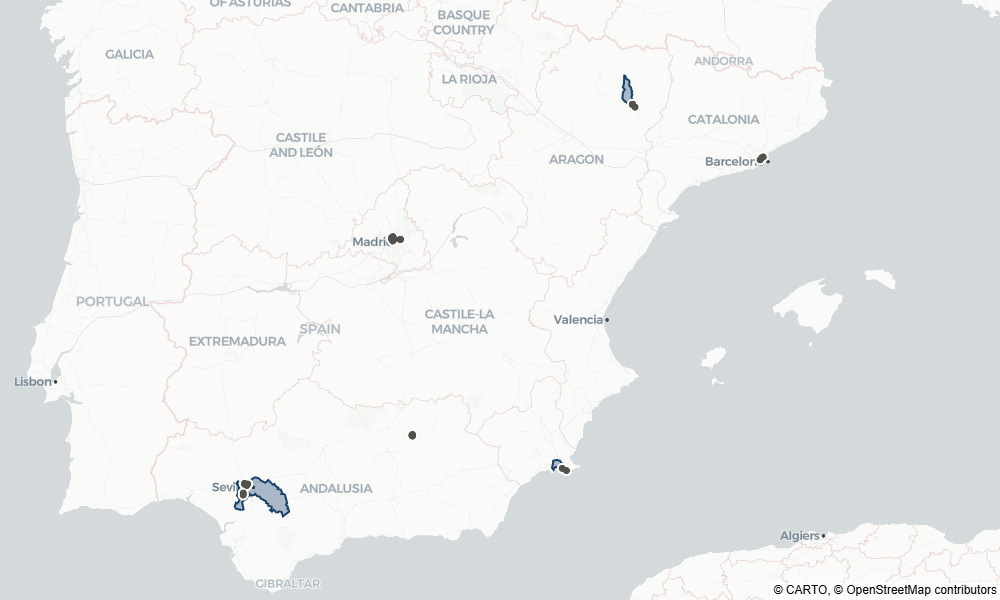

In [18]:
fig = plot_clusters(
    geometries=clusters_df["geometry"],
    cluster_names=clusters_df["cluster_name"],
    values=clusters_df["value"],
    asset_lat=assets_df["latitude"].to_list(),
    asset_lon=assets_df["longitude"].to_list(),
    asset_name=assets_df["name"].to_list(),
    hazard=hazard,
    fit_to="all",  # keep every asset in frame, not just the clustered basins
)
fig.show()

The map shows where the clusters sit. The chart below shows how the clustered value splits between them, which is what matters for correlated loss: one cluster holding a large share of the exposed value drives the portfolio tail more than several small ones.

Only assets exposed to the selected hazard are placed in a cluster, so the clustered value is a subset of the portfolio total. Assets that share a cluster can be hit by the same event and are not treated as independent in the aggregation, while assets in single-asset clusters are.


Clustered value 9.8M EUR, 21% of the 46.7M portfolio


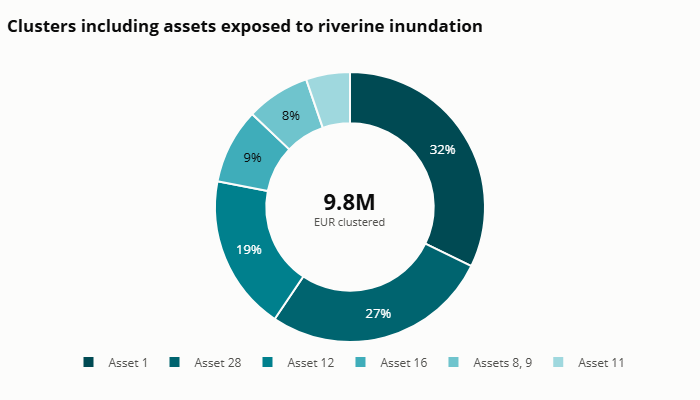

In [19]:
HAZARD_TEXT = {
    "RiverineInundation": "riverine inundation",
    "CoastalInundation": "coastal inundation",
    "Fire": "wildfire",
    "Landslide": "landslide",
    "Wind": "wind",
    "Combined": "all hazards combined",
}

cluster_labels = {
    f"Asset{'s' if len(row['assets']) > 1 else ''} {', '.join(map(str, row['assets']))}": row["value"]
    for _, row in clusters_df.iterrows()
}

clustered = clusters_df["value"].sum()
portfolio_value = assets_df["value"].sum()
print(
    f"Clustered value {clustered / 1e6:,.1f}M EUR, "
    f"{clustered / portfolio_value:.0%} of the {portfolio_value / 1e6:,.1f}M portfolio"
)

fig = cluster_exposure_donut(
    cluster_labels,
    title=f"Clusters including assets exposed to {HAZARD_TEXT.get(hazard, hazard)}",
)
fig.show()


---

## 5. Financial Metrics

### 5.1 Cluster-Level Metrics

Cluster-level metrics focus on one hazard and one cluster. They are useful when you want to understand the loss profile of a specific concentration of exposure rather than the whole portfolio.

Choose a `cluster_hazard` and `cluster_id` from the cluster output above.

The two endpoint families used here are:

- `exceedance-curves`: the full loss curve across exceedance probabilities,
- `metrics`: summary statistics such as VaR and Expected Shortfall.

In [20]:
cluster_hazard = hazard
cluster_id = clusters_df.loc[
    clusters_df["assets"].str.len().idxmax(),
    "cluster_id"
]  # We choose the cluster that contains the most assets, but any other cluster can be selected.

The next cell calls both cluster endpoints for the same cluster and hazard so that the distribution view and the summary-metric view stay aligned.

In [21]:
clusters_exceedance_curve = requests.get(
    url=f"{API_BASE}/api/physical-asset-portfolios/{portfolio_code}/clusters/{cluster_id}/exceedance-curves?hazard={cluster_hazard}", headers=headers
)

clusters_metrics = requests.get(
    url=f"{API_BASE}/api/physical-asset-portfolios/{portfolio_code}/clusters/{cluster_id}/metrics?hazard={cluster_hazard}", headers=headers
)

for response in [clusters_exceedance_curve, clusters_metrics]:
    response.raise_for_status()

The exceedance curve shows how loss severity changes as events become rarer. Moving toward lower exceedance probabilities corresponds to more severe, less frequent loss outcomes.

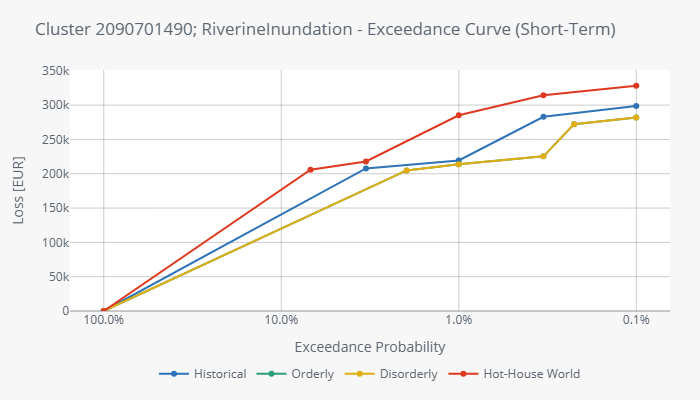

In [22]:
plot_exceedance_curves(clusters_exceedance_curve, name=f"Cluster {cluster_id}; {cluster_hazard}", selected_term="short")

Value at Risk (VaR) summarizes a high-percentile loss threshold. It answers: what loss level is exceeded only in a small fraction of cases?

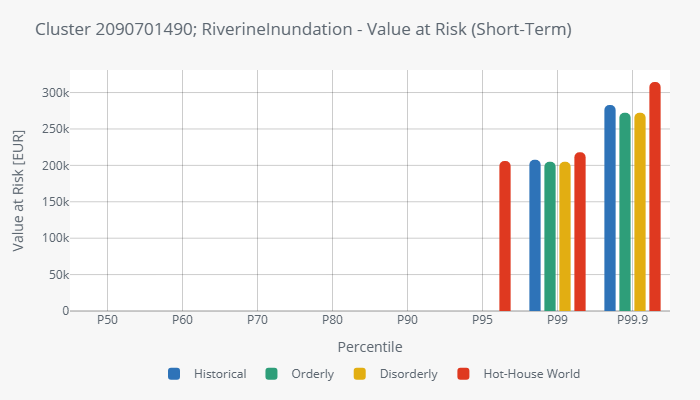

In [23]:
plot_var(clusters_metrics, name=f"Cluster {cluster_id}; {cluster_hazard}", selected_term="short")

Expected Shortfall (ES) goes one step further and averages the losses beyond the VaR threshold, making it especially useful for tail-risk interpretation.

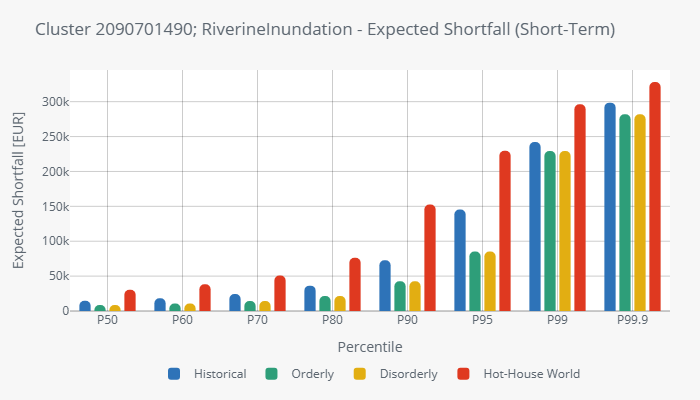

In [24]:
plot_es(clusters_metrics, name=f"Cluster {cluster_id}; {cluster_hazard}", selected_term="short")

### 5.2 Portfolio-Level Metrics

The portfolio view applies the same logic as the cluster view, but after aggregating across the entire registered portfolio.

Use the portfolio-level endpoints when you want the total risk profile rather than the contribution of one spatial cluster.

In [25]:
portfolio_hazard = "Combined"

The following cell requests portfolio-level exceedance curves and metrics for the selected portfolio hazard. These results capture how individual asset and cluster losses combine into total portfolio risk.

In [26]:
portfolio_hazard_exceedance = requests.get(
    url=f"{API_BASE}/api/physical-asset-portfolios/{portfolio_code}/exceedance-curves?hazard={portfolio_hazard}", headers=headers
)

portfolio_metrics = requests.get(
    url=f"{API_BASE}/api/physical-asset-portfolios/{portfolio_code}/metrics?hazard={portfolio_hazard}", headers=headers
)

for response in [portfolio_hazard_exceedance, portfolio_metrics]:
    response.raise_for_status()

This curve represents total portfolio losses after aggregation across all relevant assets.

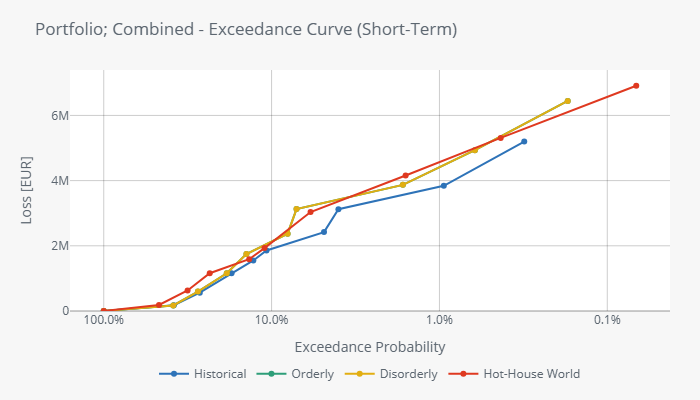

In [27]:
plot_exceedance_curves(portfolio_hazard_exceedance, name=f"Portfolio; {portfolio_hazard}", selected_term="short")

Portfolio VaR summarizes severe-but-plausible downside loss at whole-portfolio level.

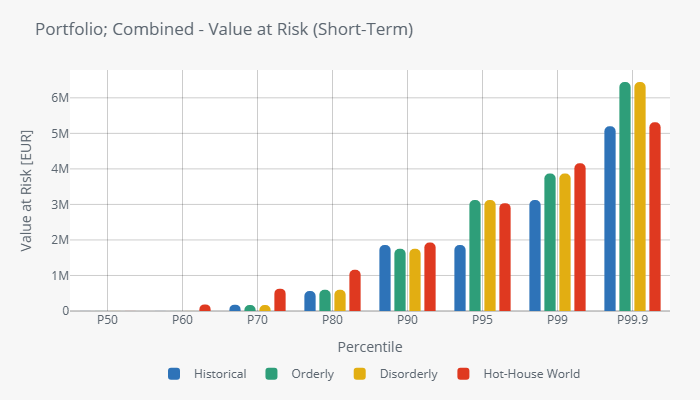

In [28]:
plot_var(portfolio_metrics, name=f"Portfolio; {portfolio_hazard}", selected_term="short")

Portfolio Expected Shortfall highlights the average severity of losses in the extreme tail and complements the VaR view.

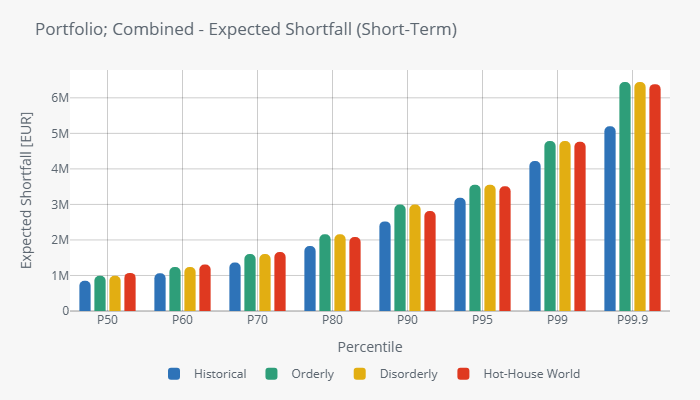

In [29]:
plot_es(portfolio_metrics, name=f"Portfolio; {portfolio_hazard}", selected_term="short")

## 6. Traceability and Methodology

This section records where each number in this notebook comes from, so results can be traced back to their source.

- Risk scores, clusters, exceedance curves and financial metrics are all computed by the Alpha-Klima platform. This notebook only reshapes the API responses into tables and charts.
- Clustering runs per hazard, and each acute hazard uses its own spatial method. The same portfolio can therefore produce a different cluster layout for each hazard. Cluster identifiers reflect the method applied: basin-based hazards return the identifier of the basin, while other hazards return sequential cluster numbers.
- The `Combined` portfolio view aggregates results across hazards and clusters rather than adding them up, so assets sharing a cluster contribute to the same event loss.
- Scenario labels are transition narratives rather than pathway identifiers. When a requested narrative has no data for a given hazard, the platform resolves it to the closest available pathway. Two narratives can therefore be served from the same underlying series, in which case their curves overlap.
- Asset values in the example portfolio are illustrative, and results are intended for screening rather than regulatory submission.
- The full methodology, covering hazard models, vulnerability curves, clustering methods and the scoring approach, is documented on the platform. Log in at https://platform.alpha-klima.com and open the documentation section.


## 7. Where This Fits in the Broader Workflow

This notebook sits between the API fundamentals and the more specialized reporting workflows. It is a good reference when a client wants to understand how raw portfolio data becomes:

- asset-level scores,
- acute-hazard clusters,
- and portfolio-level financial risk measures.